In [1]:
from google.colab import files
uploaded = files.upload()
print(uploaded)

Saving seattle-weather.csv to seattle-weather.csv
{'seattle-weather.csv': b'date,precipitation,temp_max,temp_min,wind,weather\r\n2012-01-01,0.0,12.8,5.0,4.7,drizzle\r\n2012-01-02,10.9,10.6,2.8,4.5,rain\r\n2012-01-03,0.8,11.7,7.2,2.3,rain\r\n2012-01-04,20.3,12.2,5.6,4.7,rain\r\n2012-01-05,1.3,8.9,2.8,6.1,rain\r\n2012-01-06,2.5,4.4,2.2,2.2,rain\r\n2012-01-07,0.0,7.2,2.8,2.3,rain\r\n2012-01-08,0.0,10.0,2.8,2.0,sun\r\n2012-01-09,4.3,9.4,5.0,3.4,rain\r\n2012-01-10,1.0,6.1,0.6,3.4,rain\r\n2012-01-11,0.0,6.1,-1.1,5.1,sun\r\n2012-01-12,0.0,6.1,-1.7,1.9,sun\r\n2012-01-13,0.0,5.0,-2.8,1.3,sun\r\n2012-01-14,4.1,4.4,0.6,5.3,snow\r\n2012-01-15,5.3,1.1,-3.3,3.2,snow\r\n2012-01-16,2.5,1.7,-2.8,5.0,snow\r\n2012-01-17,8.1,3.3,0.0,5.6,snow\r\n2012-01-18,19.8,0.0,-2.8,5.0,snow\r\n2012-01-19,15.2,-1.1,-2.8,1.6,snow\r\n2012-01-20,13.5,7.2,-1.1,2.3,snow\r\n2012-01-21,3.0,8.3,3.3,8.2,rain\r\n2012-01-22,6.1,6.7,2.2,4.8,rain\r\n2012-01-23,0.0,8.3,1.1,3.6,rain\r\n2012-01-24,8.6,10.0,2.2,5.1,rain\r\n2012-01-25,8

First 5 Rows of Dataset
         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-02           10.9      10.6       2.8   4.5     rain
2  2012-01-03            0.8      11.7       7.2   2.3     rain
3  2012-01-04           20.3      12.2       5.6   4.7     rain
4  2012-01-05            1.3       8.9       2.8   6.1     rain


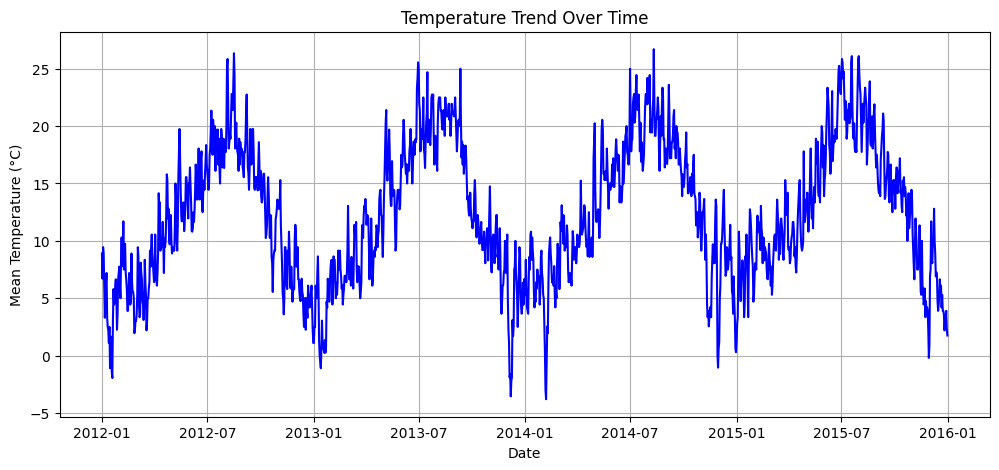


Training Samples : 1168
Testing Samples  : 293

MODEL PERFORMANCE
Mean Absolute Error (MAE) : 5.02
Root Mean Squared Error (RMSE) : 6.28

FUTURE PREDICTION 
Date : 20-08-2026
Predicted Mean Temperature : 16.67 °C


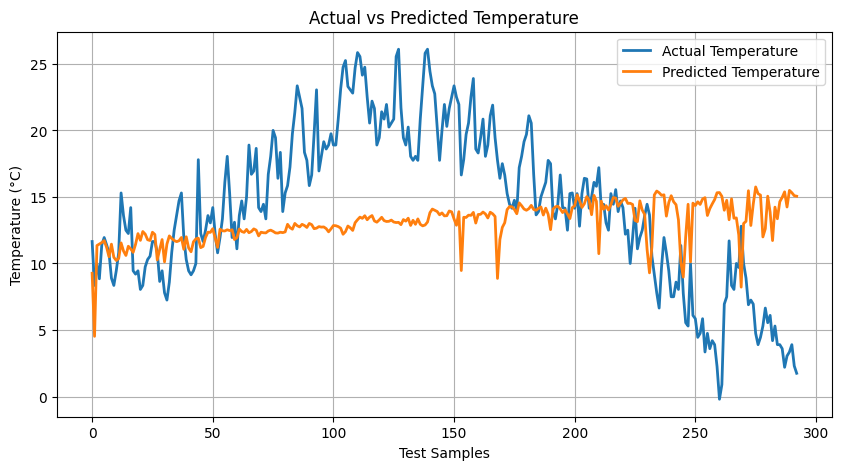

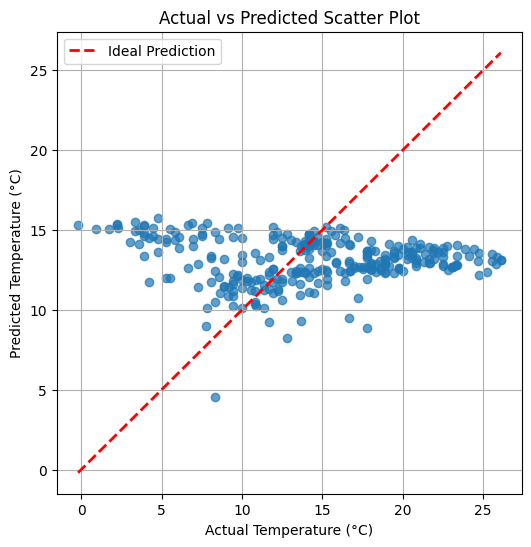

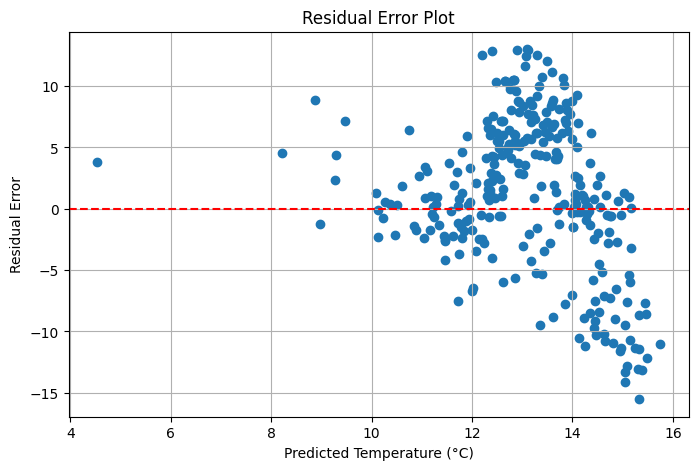

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Load Dataset
df = pd.read_csv("seattle-weather.csv")

print("First 5 Rows of Dataset")
print(df.head())


# Date Processing

df["date"] = pd.to_datetime(df["date"])

df["Year"] = df["date"].dt.year
df["Month"] = df["date"].dt.month
df["Day"] = df["date"].dt.day

# Create Mean Temperature
df["meantemp"] = ((df["temp_max"] + df["temp_min"]) / 2).round(2)


# Temperature Trend Analysis

plt.figure(figsize=(12,5))
plt.plot(df["date"], df["meantemp"], color="blue")
plt.title("Temperature Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Mean Temperature (°C)")
plt.grid(True)
plt.show()

# Select Features and Target

X = df[["Year", "Month", "Day", "precipitation", "wind"]]
y = df["meantemp"]

# Time Series Train-Test Split

split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("\nTraining Samples :", len(X_train))
print("Testing Samples  :", len(X_test))


# Train Linear Regression Model

model = LinearRegression()

model.fit(X_train, y_train)


# Predict Test Data

pred = model.predict(X_test)


# Model Evaluation

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("\nMODEL PERFORMANCE")
print("Mean Absolute Error (MAE) :", round(mae,2))
print("Root Mean Squared Error (RMSE) :", round(rmse,2))


# Future Weather Prediction
# NOTE:
# Precipitation is measured in millimeters (mm)
# Wind is measured in meters/second

future = pd.DataFrame({
    "Year": [2026],
    "Month": [8],
    "Day": [20],
    "precipitation": [2.5],
    "wind": [3.8]
})

future_prediction = model.predict(future)

print("\nFUTURE PREDICTION ")
print("Date : 20-08-2026")
print("Predicted Mean Temperature :",
      round(future_prediction[0],2), "°C")


# Actual vs Predicted Line Graph

plt.figure(figsize=(10,5))

plt.plot(
    y_test.values,
    label="Actual Temperature",
    linewidth=2
)

plt.plot(
    pred,
    label="Predicted Temperature",
    linewidth=2
)

plt.title("Actual vs Predicted Temperature")
plt.xlabel("Test Samples")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)

plt.show()


# Scatter Plot

plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2,
    label="Ideal Prediction"
)

plt.xlabel("Actual Temperature (°C)")
plt.ylabel("Predicted Temperature (°C)")
plt.title("Actual vs Predicted Scatter Plot")
plt.legend()
plt.grid(True)

plt.show()

# Residual Error Plot (Optional but Useful)

errors = y_test - pred

plt.figure(figsize=(8,5))

plt.scatter(pred, errors)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Temperature (°C)")
plt.ylabel("Residual Error")
plt.title("Residual Error Plot")

plt.grid(True)

plt.show()

